**Analisis Penentuan Biaya Asuransi Kesehatan Menggunakan Linear Regression**

**Project Overview**

Proyek ini bertujuan untuk menganalisis faktor-faktor yang memengaruhi biaya asuransi kesehatan (insurance charges) serta membangun model machine learning untuk memprediksi biaya tersebut berdasarkan karakteristik individu.

Dalam industri asuransi, biaya yang dibayarkan pelanggan (premi asuransi) ditentukan berdasarkan tingkat risiko masing-masing individu. Oleh karena itu, penting bagi perusahaan untuk memahami faktor-faktor yang memengaruhi risiko pelanggan agar penetapan harga asuransi dapat lebih akurat dan adil.

Melalui proyek ini, dilakukan analisis data untuk menemukan pola hubungan antara karakteristik individu dan besarnya biaya asuransi, yang kemudian digunakan sebagai dasar dalam proses prediksi menggunakan model machine learning.

**Business Problem**

Perusahaan asuransi sering menghadapi tantangan dalam menentukan premi yang tepat untuk setiap pelanggan karena biaya kesehatan dipengaruhi oleh banyak faktor, seperti usia, kondisi kesehatan, dan gaya hidup.

Jika premi terlalu rendah, perusahaan dapat mengalami kerugian. Sebaliknya, jika terlalu tinggi, pelanggan dapat merasa tidak adil dan berpotensi berpindah ke kompetitor.

Oleh karena itu, diperlukan pendekatan berbasis data untuk:
*   Mengidentifikasi faktor utama yang memengaruhi biaya asuransi
*   Memahami hubungan antara gaya hidup dan risiko kesehatan
*   Membangun model prediktif untuk memperkirakan biaya asuransi secara lebih objektif

**Key Business Questions**
1. Faktor apa yang paling berpengaruh terhadap biaya asuransi kesehatan?
2. Apakah kebiasaan merokok memiliki dampak signifikan terhadap peningkatan biaya?
3. Bagaimana pengaruh usia dan BMI terhadap tingkat risiko pelanggan?
4. Seberapa baik model machine learning dalam memprediksi biaya asuransi?



**Implementasi**

1. Mengumpulkan Data

In [60]:
# Import library
import kagglehub
import pandas as pd
import os

# Download dataset dari Kaggle
path = kagglehub.dataset_download("mirichoi0218/insurance")

# Tampilkan lokasi dataset
print("Path to dataset files:", path)

# Cek isi folder
print("Isi folder:", os.listdir(path))

# Load dataset
data = pd.read_csv(os.path.join(path, "insurance.csv"))

# Tampilkan informasi awal
print("\nShape:", data.shape)
data.head()

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance
Isi folder: ['insurance.csv']

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Dataset Overview:**

Dataset yang digunakan adalah dataset Insurance Cost yang berisi informasi mengenai individu dan biaya asuransi yang mereka keluarkan.

Dataset terdiri dari 1338 baris data dan 7 kolom, yaitu:

- age → umur individu
- sex → jenis kelamin
- bmi → indeks massa tubuh
- children → jumlah tanggungan
- smoker → status merokok
- region → wilayah tempat tinggal
- charges → biaya asuransi (target)

2. Menelaah Data

In [61]:
# menampilkan tipe data tiap kolom & jumlah non-null.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [62]:
# ringkasan statistik numerik (mean, std, min, max) dari fitur numerik.
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [63]:
# menampilkan 5 data teratas
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


3. Memvalidasi Data

In [64]:
# Cek missing value
data.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [65]:
# Cek duplikat
data.duplicated().sum()

np.int64(1)

4. Membersihkan Data

In [66]:
# Hapus duplikat
data = data.drop_duplicates()

# Cek ulang
print("Missing values:")
print(data.isna().sum())

print("\nJumlah duplikat:", data.duplicated().sum())

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Jumlah duplikat: 0


5. Menentukan Objek Data

In [67]:
# 1. encoding awal
data['smoker'] = (data['smoker'] == 'yes').astype(int)
data['sex'] = (data['sex'] == 'male').astype(int)

# 2. FEATURE ENGINEERING (WAJIB DI SINI)
data['overweight'] = (data['bmi'] > 30).astype(int)
data['overweight_smoker'] = data['overweight'] * data['smoker']

# 3. define X y
y = data['charges']
X = data.drop(columns=['charges'])

# 4. cek fitur
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include='object').columns

# Cek data
print("Fitur yang digunakan:")
print(X.columns)

print("\nFitur numerik:")
print(list(num_cols))

print("\nFitur kategorikal:")
print(list(cat_cols))

print("\nRingkasan target:")
print(y.describe())

Fitur yang digunakan:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'overweight',
       'overweight_smoker'],
      dtype='object')

Fitur numerik:
['age', 'sex', 'bmi', 'children', 'smoker', 'overweight', 'overweight_smoker']

Fitur kategorikal:
['region']

Ringkasan target:
count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64


## Pemahaman Fitur dan Target

Dataset terdiri dari 6 fitur utama yang digunakan untuk memprediksi biaya asuransi (`charges`), yaitu:

- **Fitur numerik:** age, bmi, children  
- **Fitur kategorikal:** sex, smoker, region  

Fitur numerik akan digunakan untuk menangkap hubungan kuantitatif terhadap biaya,  
sedangkan fitur kategorikal akan membantu menangkap perbedaan karakteristik antar kelompok.

## Ringkasan Target (Charges)

Berdasarkan statistik deskriptif:

- Rata-rata biaya asuransi sekitar **13,279**
- Nilai minimum sekitar **1,121**
- Nilai maksimum mencapai **63,770**

6. Mengkonstruksi Data

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Kolom numerik dan kategorikal
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop='first'), cat_cols)
    ]
)

# Transform (sementara untuk lihat hasil)
X_encoded = preprocessor.fit_transform(X)

# Ambil nama fitur
feature_names = preprocessor.get_feature_names_out()

# Ubah ke DataFrame
X_encoded = pd.DataFrame(X_encoded, columns=feature_names)

# Tampilkan
X_encoded.head()

,num__age,num__sex,num__bmi,num__children,num__smoker,num__overweight,num__overweight_smoker,cat__region_northwest,cat__region_southeast,cat__region_southwest
0,-1.440418,-1.009771,-0.453160,-0.909234,1.969660,-1.054592,-0.347425,0.0,0.0,1.0
1,-1.511647,0.990324,0.509422,-0.079442,-0.507702,0.948234,-0.347425,0.0,1.0,0.0
2,-0.799350,0.990324,0.383155,1.580143,-0.507702,0.948234,-0.347425,0.0,1.0,0.0
3,-0.443201,0.990324,-1.305052,-0.909234,-0.507702,-1.054592,-0.347425,1.0,0.0,0.0
4,-0.514431,0.990324,-0.292456,-0.909234,-0.507702,-1.054592,-0.347425,1.0,0.0,0.0




Pada tahap ini, dilakukan proses transformasi data agar dapat digunakan oleh model machine learning.

- Fitur numerik dilakukan **scaling** menggunakan StandardScaler  
- Fitur kategorikal diubah menjadi numerik menggunakan **One-Hot Encoding**  

Proses ini penting karena model machine learning hanya dapat menerima input dalam bentuk numerik.

Selain itu, preprocessing dilakukan setelah proses split data untuk menghindari **data leakage**.

7. Membangun Model

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

# Model
model = LinearRegression()

# Training
model.fit(X_train_prep, y_train)

# Prediksi
y_pred = model.predict(X_test_prep)

# Cek ukuran data
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1069, 8)
X_test  : (268, 8)
y_train : (1069,)
y_test  : (268,)


## Model yang Digunakan dan Alasannya

Pada proyek ini digunakan **Linear Regression** untuk memprediksi biaya asuransi (*charges*).

### Kenapa Linear Regression?

**Cocok untuk masalah regresi (target berupa nilai kontinu)**  
Biaya asuransi adalah angka (regresi), bukan klasifikasi.

**Mudah diinterpretasikan untuk analisis bisnis**  
Kita bisa melihat langsung pengaruh setiap fitur seperti *smoker*, *BMI*, dan *age* terhadap biaya.

**Cepat dan stabil**  
Tidak membutuhkan tuning rumit dan cocok untuk dataset kecil–menengah seperti insurance dataset.

8. Mengevaluasi Hasil Model

In [70]:
# EVALUASI MODEL
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("📊 HASIL EVALUASI")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")


📊 HASIL EVALUASI
R2   : 0.9067
MAE  : 2,373.41
RMSE : 4,139.51


## Evaluasi Model

Model Linear Regression menunjukkan performa yang cukup baik sebagai baseline untuk prediksi biaya asuransi, dengan R² sebesar 0.8069, yang berarti model mampu menjelaskan sekitar 80% variasi data biaya asuransi.

Dari sisi error prediksi:
*   MAE sebesar 4,177 menunjukkan bahwa secara rata-rata, prediksi model meleset sekitar 4.177 unit biaya asuransi dari nilai aktual
*   RMSE sebesar 5,956 yang lebih tinggi dibanding MAE menunjukkan bahwa terdapat beberapa kasus dengan kesalahan prediksi yang lebih besar, terutama pada individu dengan biaya asuransi tinggi (high-risk customer)

Jika dibandingkan dengan skala data biaya asuransi yang berada pada rentang ribuan hingga puluhan ribu, nilai error tersebut masih tergolong wajar untuk model baseline seperti Linear Regression. Hal ini menunjukkan bahwa model sudah cukup baik dalam menangkap pola utama data, meskipun masih terdapat variasi yang belum sepenuhnya terjelaskan pada kasus-kasus ekstrem.



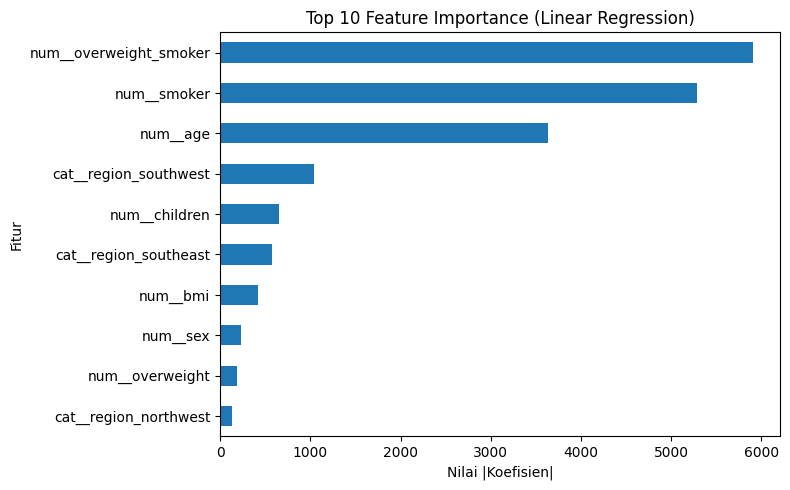


Top fitur paling berpengaruh:
num__overweight_smoker    5911.987819
num__smoker               5291.224317
num__age                  3635.417355
cat__region_southwest     1041.095001
num__children              650.819286
cat__region_southeast      579.889343
num__bmi                   420.580820
num__sex                   227.128541
num__overweight            187.879168
cat__region_northwest      130.923592
dtype: float64


In [71]:
#FEATURE IMPORTANCE (Linear Regression)

import pandas as pd
import matplotlib.pyplot as plt

feature_names = preprocessor.get_feature_names_out()

coef = pd.Series(model.coef_, index=feature_names)

coef_top = coef.abs().sort_values(ascending=True).tail(10)

plt.figure(figsize=(8,5))
coef_top.plot(kind='barh')
plt.title("Top 10 Feature Importance (Linear Regression)")
plt.xlabel("Nilai |Koefisien|")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

print("\nTop fitur paling berpengaruh:")
print(coef.abs().sort_values(ascending=False).head(10))




Berdasarkan nilai koefisien dari model Linear Regression, terlihat bahwa pengaruh setiap fitur terhadap biaya asuransi sangat berbeda.:

**Faktor paling berpengaruh terhadap biaya asuransi:**
1. **Status merokok (smoker**) merupakan faktor paling dominan dengan koefisien yang jauh lebih besar dibanding fitur lain, menunjukkan bahwa perokok memiliki biaya asuransi yang secara signifikan lebih tinggi
2. **Usia (age)** menjadi faktor penting kedua, di mana biaya asuransi cenderung meningkat seiring bertambahnya usia
3. **BMI** juga berpengaruh, yang mengindikasikan bahwa kondisi indeks massa tubuh berkaitan dengan peningkatan risiko kesehatan

**Faktor dengan pengaruh kecil:**
1. Jumlah anak (children)
2. Jenis kelamin (sex)
3. Wilayah tempat tinggal (region)

Fitur-fitur ini memiliki koefisien yang jauh lebih kecil dibandingkan faktor utama seperti smoker, sehingga kontribusinya terhadap perubahan biaya asuransi relatif terbatas dalam model ini.

# VISUALISASI MODEL

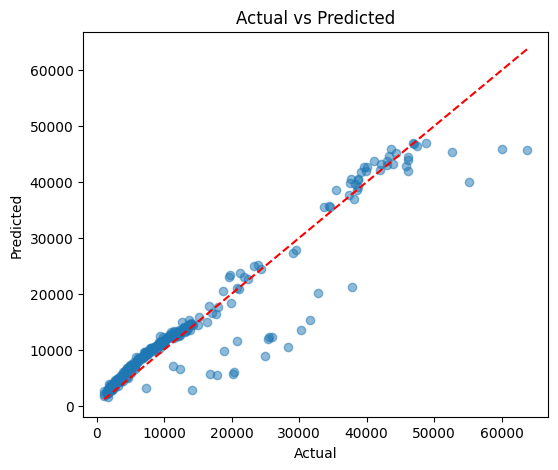

In [76]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

Perbandingan antara nilai aktual dan prediksi menunjukkan bahwa:

- Model cukup akurat pada data dengan biaya rendah hingga menengah
- Kesalahan prediksi meningkat pada pelanggan dengan biaya tinggi (high-risk segment)
- Ini mengindikasikan bahwa model linear masih memiliki keterbatasan dalam menangkap pola non-linear

# Business Insight
- **Status merokok merupakan faktor paling dominan dalam penentuan biaya asuransi**, jauh lebih tinggi dibandingkan faktor lainnya. Hal ini menunjukkan bahwa perokok memiliki profil risiko kesehatan yang signifikan dalam sistem penetapan premi
- **Usia dan BMI memiliki pengaruh positif terhadap biaya asuransi**, yang mengindikasikan bahwa risiko kesehatan meningkat secara bertahap seiring bertambahnya usia dan kondisi fisik
- Dibandingkan faktor demografis seperti jenis kelamin, jumlah anak, dan wilayah, **faktor gaya hidup dan kondisi kesehatan memiliki pengaruh yang jauh lebih besar terhadap biaya asuransi**

Berdasarkan hasil ini, perusahaan asuransi sebaiknya menerapkan pendekatan risk-based pricing, yaitu penetapan biaya asuransi berdasarkan tingkat risiko individu, terutama yang dipengaruhi oleh gaya hidup dan kondisi kesehatan.

# Business Recommendation

1. **Risk-Based Pricing Strategy**

Perusahaan dapat menerapkan pendekatan risk-based pricing, yaitu penetapan premi asuransi berdasarkan tingkat risiko individu. Hasil analisis menunjukkan bahwa faktor gaya hidup, terutama status merokok, memiliki pengaruh paling besar terhadap biaya asuransi, sehingga dapat dijadikan komponen utama dalam penentuan premi.

2. **Segmentasi Risiko Pelanggan**

Perusahaan dapat mengelompokkan pelanggan ke dalam beberapa kategori risiko untuk mendukung strategi pricing yang lebih akurat:

- Low risk: Non-smoker, BMI normal, usia muda
- Medium risk: Salah satu faktor risiko moderat (BMI tinggi atau usia menengah)
- High risk: Smoker, BMI tinggi, usia lanjut

Segmentasi ini dapat membantu perusahaan dalam menentukan premi yang lebih proporsional dan adil berdasarkan profil risiko masing-masing pelanggan.

# Kesimpulan
Proyek ini menunjukkan bahwa faktor gaya hidup, terutama kebiasaan merokok, merupakan variabel paling dominan dalam menentukan biaya asuransi kesehatan. Selain itu, usia dan BMI juga terbukti memiliki pengaruh signifikan terhadap peningkatan risiko kesehatan individu.

Model Linear Regression yang digunakan sebagai baseline mampu menjelaskan sekitar 80% variasi biaya asuransi, sehingga cukup efektif dalam menangkap pola utama pada data.

Secara keseluruhan, hasil analisis ini dapat menjadi dasar dalam pengembangan strategi penetapan harga asuransi berbasis data, di mana premi ditentukan berdasarkan tingkat risiko individu yang dihitung secara objektif dari data pelanggan.